# 8. Imbalance strategies

**Question: does rebalancing the training data beat simply moving the threshold?**

This is the notebook most likely to overturn a habit.

The standard response to 1.7% positives is to rebalance: undersample the majority,
synthesise minority points with SMOTE, or weight the classes. All three change what the
model learns. But there is a fourth option that changes nothing about training at all —
leave the data alone and move the decision threshold.

Since every model in this study already gets a cost-optimal threshold, the fair question
is not "does rebalancing beat 0.5" — it obviously does — but **"does rebalancing beat
threshold tuning?"**

One correctness note: resampling happens strictly inside a fit-only
`imbalanced-learn` pipeline. Validation, calibration, threshold and test data are never
resampled. Synthesising SMOTE points before splitting is the classic way to publish a
result that evaporates in production.

> **The objective.** Every number in this notebook is judged against
> `J = 10·FP + 500·FN`. A false positive is an unnecessary inspection; a false
> negative is a truck that fails in service. Missing one failure costs as much
> as fifty needless inspections, and that ratio is what makes the modelling
> choices here matter.

In [1]:
from pathlib import Path

import pandas as pd

from scania_aps.data import TEST_FILENAME, TRAIN_FILENAME, read_raw_csv
from scania_aps.plotting import apply_house_style

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
TRAIN = ROOT / "data" / "raw" / TRAIN_FILENAME
TEST = ROOT / "data" / "raw" / TEST_FILENAME
ARTIFACTS = ROOT / "artifacts"
assert TRAIN.exists() and TEST.exists(), "Run: poetry run scania-aps download"

apply_house_style()

train = read_raw_csv(TRAIN)
test = read_raw_csv(TEST)

pd.DataFrame(
    {
        "trucks": [len(train.y), len(test.y)],
        "features": [train.X.shape[1], test.X.shape[1]],
        "failures": [int(train.y.sum()), int(test.y.sum())],
        "failure_rate": [train.y.mean(), test.y.mean()],
    },
    index=["training set", "official test set"],
)

,trucks,features,failures,failure_rate
training set,60000,170,1000,0.016667
official test set,16000,170,375,0.023438


In [2]:
from scania_aps.studies import run_imbalance_study

imbalance = run_imbalance_study(TRAIN, TEST, ARTIFACTS)
imbalance

C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,strategy,threshold,total_cost,cost_per_observation,false_positives,false_negatives,precision,recall,pr_auc,roc_auc,always_negative_cost,always_positive_cost,saving_vs_always_negative,saving_vs_always_positive,score_kind,brier,log_loss
1,class_weight,0.176567,16630.0,1.039375,613,21,0.366081,0.944000,0.811230,0.982849,187500.0,156250.0,170870.0,139620.0,probability,0.014527,0.075731
0,none,0.022135,17520.0,1.095000,652,22,0.351244,0.941333,0.823081,0.985554,187500.0,156250.0,169980.0,138730.0,probability,0.007890,0.035662
2,undersample,0.410588,17690.0,1.105625,669,22,0.345401,0.941333,0.748104,0.989648,187500.0,156250.0,169810.0,138560.0,probability,0.031115,0.173245
4,focal_loss_mlp,0.409213,18120.0,1.132500,362,29,0.488701,0.922667,0.826836,0.991419,187500.0,156250.0,169380.0,138130.0,probability,0.023081,0.136511
3,smote,0.386358,18580.0,1.161250,508,27,0.406542,0.928000,0.800669,0.973665,187500.0,156250.0,168920.0,137670.0,probability,0.022166,0.123456


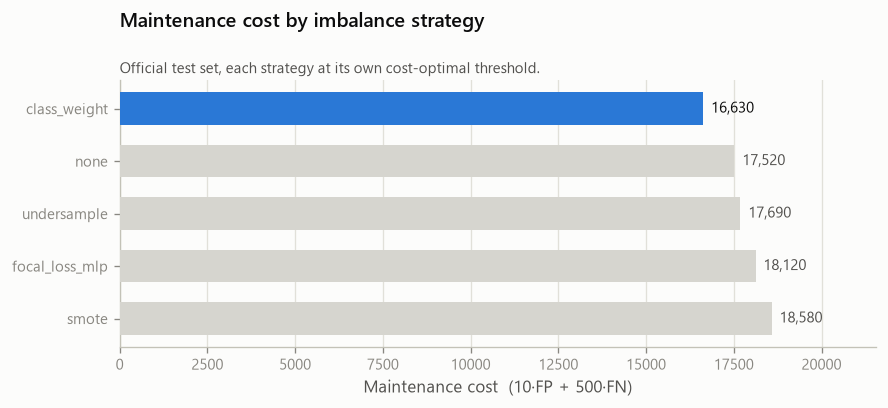

In [3]:
from scania_aps.plotting import emphasis_bars

label_column = "strategy" if "strategy" in imbalance.columns else imbalance.columns[0]

fig, ax = emphasis_bars(
    [str(v) for v in imbalance[label_column]],
    [float(v) for v in imbalance["total_cost"].to_numpy()],
    title="Maintenance cost by imbalance strategy",
    subtitle="Official test set, each strategy at its own cost-optimal threshold.",
    xlabel="Maintenance cost  (10·FP + 500·FN)",
)

## The error trade behind the cost

A single cost number hides *how* each strategy got there. Two strategies can cost the
same while making very different mistakes, and for a maintenance planner the mix
matters: false negatives are trucks that break down, false positives are workshop
hours.

In [4]:
errors = imbalance[
    [label_column, "false_negatives", "false_positives", "recall", "precision", "total_cost"]
].copy()
errors["cost_from_fn"] = errors["false_negatives"] * 500
errors["cost_from_fp"] = errors["false_positives"] * 10
errors["fn_share_of_cost"] = errors["cost_from_fn"] / errors["total_cost"]
errors.sort_values("total_cost")

,strategy,false_negatives,false_positives,recall,precision,total_cost,cost_from_fn,cost_from_fp,fn_share_of_cost
1,class_weight,21,613,0.944000,0.366081,16630.0,10500,6130,0.631389
0,none,22,652,0.941333,0.351244,17520.0,11000,6520,0.627854
2,undersample,22,669,0.941333,0.345401,17690.0,11000,6690,0.621820
4,focal_loss_mlp,29,362,0.922667,0.488701,18120.0,14500,3620,0.800221
3,smote,27,508,0.928000,0.406542,18580.0,13500,5080,0.726588


### Reading the result

**Two of the three rebalancing strategies lose to doing nothing at all.**

Undersampling and SMOTE both cost more than the uncorrected baseline, and SMOTE — the
most elaborate of them, and by far the slowest to fit — is the most expensive strategy
in the table. Only class weighting improves on the baseline, and it does so narrowly.

This is the notebook's point, and it is worth stating plainly: **once the threshold is
chosen on cost, rebalancing the training data has almost nothing left to contribute.**
Both mechanisms are trying to solve the same problem — that the model is reluctant to
predict the rare class — and the threshold solves it directly, at the decision, without
touching what the model learned. Applying both does not compound the benefit; it mostly
re-does it.

SMOTE deserves the sharpest reading. Synthesising minority points interpolates between
real failures in a 170-dimensional space where the features are anonymised sensor
aggregates. There is no guarantee that a point halfway between two failed trucks
corresponds to any physically realisable truck, and the cost column suggests it does not
help the model find real ones.

Then look at `fn_share_of_cost`: between 62% and 80% for every strategy. The bill is
dominated by missed failures no matter what was done to the training distribution, which
is the arithmetic saying the job is recall, bought as cheaply as possible in inspections.

The practical recommendation is the boring one: skip the resampling, keep the class
weight if it helps, and spend the effort on the threshold instead. That is a much cheaper
intervention — and unlike SMOTE it costs nothing at fit time.

**Next:** [09 — probability calibration](09_probability_calibration.ipynb), which asks
whether the scores being thresholded mean anything.